# Dataset helper functions

In [2]:
import kagglehub
path = kagglehub.dataset_download("gpreda/chinese-mnist")
print("Path to dataset files:", path)

import pandas as pd
import matplotlib.pyplot as plt
import torch
from PIL import Image
import os

# this class construction codes are obtained from https://www.kaggle.com/code/tomasrando/perceptron-multicapa-con-dropout
# thank Tomas Rando for sharing his work
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

class ChineseNumbersDataset(Dataset):
    def __init__(self, data, img_dir, transform=None):
        self.data = data
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]

        img_name = f"input_{row['suite_id']}_{row['sample_id']}_{row['code']}.jpg"
        img_path = os.path.join(self.img_dir, img_name)

        image = Image.open(img_path).convert("RGB")

        if self.transform: 
            image = self.transform(image)

        label = int(row['code']) - 1

        return image, label



# # since three channels are all the same...only use one channel
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),        # a tensor
    # transforms.Normalize((0.5,), (0.5,)) # normalizar
])


Path to dataset files: /home2/jianhuang/.cache/kagglehub/datasets/gpreda/chinese-mnist/versions/7


In [3]:
df = pd.read_csv(os.path.join(path, "chinese_mnist.csv"))
print("\n Snip \n")
print(df.head())
print("\n Description \n")
print(df.info())
print("\n CLASSES \n")
print(df['value'].unique())

# dataset = ChineseNumbersDataset(df, os.path.join(path, "data/data/"), transform = transform)


 Snip 

   suite_id  sample_id  code  value character
0         1          1    10      9         九
1         1         10    10      9         九
2         1          2    10      9         九
3         1          3    10      9         九
4         1          4    10      9         九

 Description 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   suite_id   15000 non-null  int64 
 1   sample_id  15000 non-null  int64 
 2   code       15000 non-null  int64 
 3   value      15000 non-null  int64 
 4   character  15000 non-null  object
dtypes: int64(4), object(1)
memory usage: 586.1+ KB
None

 CLASSES 

[        9        10       100      1000     10000 100000000         0
         1         2         3         4         5         6         7
         8]


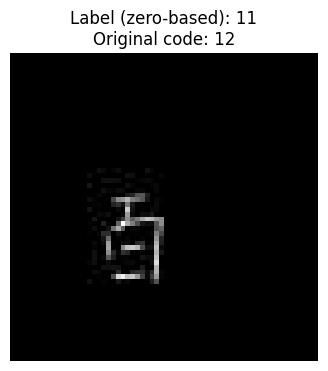

In [7]:
img_dir = os.path.join(path, "data/data/")
dataset = ChineseNumbersDataset(df, img_dir, transform=transform)

# pick any index you want to inspect
idx = 2957

image_tensor, label_tensor = dataset[idx]  # <-- uses __getitem__
label = label_tensor
img = image_tensor.clone()

if image_tensor.ndim == 3:
    # img = img * std[:, None, None] + mean[:, None, None]  # unnormalize
    img = img.permute(1, 2, 0).cpu().numpy()  # (H, W, C)
# else:
    # raise ValueError("Expected a 3D tensor (C, H, W)")

plt.figure(figsize=(4, 4))
plt.imshow(img.clip(0, 1), cmap="gray")  # clip in case of slight float errors
plt.axis("off")
plt.title(f"Label (zero-based): {label}\nOriginal code: {label + 1}")
plt.show()

In [8]:
df[(df['suite_id'] == 20) & (df['sample_id'] == 5)]

,suite_id,sample_id,code,value,character
135,20,5,10,9,九
1135,20,5,11,10,十
2135,20,5,12,100,百
3135,20,5,13,1000,千
4135,20,5,14,10000,万
5135,20,5,15,100000000,亿
6135,20,5,1,0,零
7135,20,5,2,1,一
8135,20,5,3,2,二
9135,20,5,4,3,三


In [9]:
image_tensor.shape

torch.Size([1, 64, 64])

In [10]:
image_tensor

tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]])

# Generate dataset for downstream training

In [15]:
from sklearn.model_selection import train_test_split

df["label"] = df["code"] - 1

# 1) Train + temp split
train_df, temp_df = train_test_split(
    df, 
    test_size=0.3,            # 70% train, 30% temp
    stratify=df["label"], 
    random_state=42
)

# 2) Split temp into validation and test
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,            # half of the remainder
    stratify=temp_df["label"],
    random_state=42
)

print(len(train_df), len(val_df), len(test_df))


10500 2250 2250


In [32]:
img_dir = os.path.join(path, "data/data/")
train_dataset = ChineseNumbersDataset(train_df, img_dir, transform=transform)
val_dataset   = ChineseNumbersDataset(val_df,   img_dir, transform=transform)
test_dataset  = ChineseNumbersDataset(test_df,  img_dir, transform=transform)

In [19]:
print(train_df['label'].value_counts())
print(val_df['label'].value_counts())
print(test_df['label'].value_counts())

label
3     700
6     700
10    700
5     700
9     700
11    700
12    700
7     700
8     700
2     700
4     700
0     700
14    700
1     700
13    700
Name: count, dtype: int64
label
10    150
4     150
9     150
7     150
0     150
8     150
12    150
13    150
14    150
1     150
3     150
11    150
6     150
2     150
5     150
Name: count, dtype: int64
label
1     150
7     150
11    150
9     150
0     150
3     150
8     150
4     150
14    150
2     150
12    150
13    150
6     150
5     150
10    150
Name: count, dtype: int64


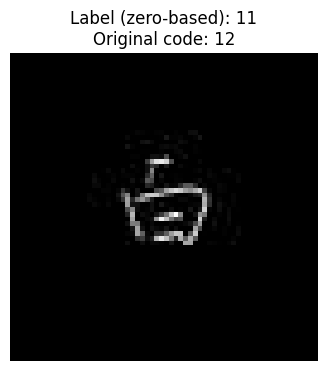

In [43]:
import random
# pick random sample idx
idx = random.randint(0, len(train_dataset) - 1)

img, label = train_dataset[idx]
img_np = img.squeeze(0).numpy() 

plt.figure(figsize=(4, 4))
plt.imshow(img_np, cmap='gray')  # clip in case of slight float errors
plt.axis("off")
plt.title(f"Label (zero-based): {label}\nOriginal code: {label + 1}")
plt.show()

In [40]:
img.shape

torch.Size([1, 64, 64])

# Perceptron class

In [44]:
import torch
import torch.nn as nn

# Dictionary of available activation functions
ACTIVATIONS = {
    "sigmoid": nn.Sigmoid(),
    "relu": nn.ReLU(),
    "tanh": nn.Tanh(),
    "leakyrelu": nn.LeakyReLU(),
    "gelu": nn.GELU(),
}

class Perceptron(nn.Module):
    def __init__(self, input_dim, hidden_layers, output_dim,
                 activation="sigmoid"):
        """
        input_dim:   number of input features (e.g. flattened image size)
        hidden_layers: list, number of neurons in each hidden layer
                       e.g. [128, 64]
        output_dim:  number of classes (15 for Chinese-MNIST)
        activation:  activation function name (default: 'sigmoid')
        """

        super(Perceptron, self).__init__()

        if activation not in ACTIVATIONS:
            raise ValueError(f"Unknown activation '{activation}'. "
                             f"Choose from: {list(ACTIVATIONS.keys())}")

        self.activation = ACTIVATIONS[activation]

        # Build layers
        layers = []
        prev_dim = input_dim

        for n_units in hidden_layers:
            layers.append(nn.Linear(prev_dim, n_units))
            layers.append(self.activation)
            prev_dim = n_units

        # Final classification layer (no activation)
        layers.append(nn.Linear(prev_dim, output_dim))

        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)


# Training

In [45]:
import torch.optim as optim
from torch.utils.data import DataLoader

In [50]:
# --- Hyperparameters ---
input_dim = 64 * 64  # flatten your 64x64 images
hidden_layers = [128, 64]
output_dim = 15
activation = "sigmoid"
batch_size = 64
epochs = 50
learning_rate = 0.001

# --- Device ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# --- DataLoaders ---
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# --- Model ---
model = Perceptron(input_dim, hidden_layers, output_dim, activation)
model.to(device)

# --- Loss and optimizer ---
criterion = nn.CrossEntropyLoss()  # good for multi-class classification
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# --- Training loop ---
train_loss_history = []
train_acc_history = []
val_loss_history = []
val_acc_history = []
for epoch in range(1, epochs + 1):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        # Flatten images: (B, 1, 64, 64) -> (B, 64*64)
        images = images.view(images.size(0), -1).to(device)
        labels = labels.to(device)

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Statistics
        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    train_loss = running_loss / total
    train_acc = correct / total
    train_loss_history.append(train_loss)
    train_acc_history.append(train_acc)

    # --- Validation / Testing ---
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.view(images.size(0), -1).to(device)
            labels = labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    val_loss /= total
    val_acc = correct / total
    val_loss_history.append(val_loss)
    val_acc_history.append(val_acc)

    print(f"Epoch [{epoch}/{epochs}] "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

Using device: cuda
Epoch [1/50] Train Loss: 2.6648, Train Acc: 0.1391 | Val Loss: 2.5520, Val Acc: 0.2289
Epoch [2/50] Train Loss: 2.3705, Train Acc: 0.2822 | Val Loss: 2.1936, Val Acc: 0.3422
Epoch [3/50] Train Loss: 2.0333, Train Acc: 0.3905 | Val Loss: 1.9405, Val Acc: 0.4018
Epoch [4/50] Train Loss: 1.8051, Train Acc: 0.4503 | Val Loss: 1.7933, Val Acc: 0.4564
Epoch [5/50] Train Loss: 1.6576, Train Acc: 0.4922 | Val Loss: 1.6988, Val Acc: 0.4796
Epoch [6/50] Train Loss: 1.5449, Train Acc: 0.5221 | Val Loss: 1.6181, Val Acc: 0.5107
Epoch [7/50] Train Loss: 1.4433, Train Acc: 0.5584 | Val Loss: 1.5378, Val Acc: 0.5204
Epoch [8/50] Train Loss: 1.3468, Train Acc: 0.5928 | Val Loss: 1.4615, Val Acc: 0.5484
Epoch [9/50] Train Loss: 1.2507, Train Acc: 0.6239 | Val Loss: 1.3815, Val Acc: 0.5733
Epoch [10/50] Train Loss: 1.1606, Train Acc: 0.6550 | Val Loss: 1.3068, Val Acc: 0.5911
Epoch [11/50] Train Loss: 1.0763, Train Acc: 0.6829 | Val Loss: 1.2444, Val Acc: 0.6116
Epoch [12/50] Train Lo

In [48]:
def plot_losses(train_losses, val_losses):
    """
    Plots training and test losses on the same figure.
    
    train_losses: list of floats
    test_losses:  list of floats
    """
    plt.figure(figsize=(8, 5))
    plt.plot(train_losses, label="Train Loss", marker='o')
    plt.plot(val_losses, label="Val Loss", marker='s')
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training and Test Loss Over Epochs")
    plt.legend()
    plt.grid(True)
    plt.show()

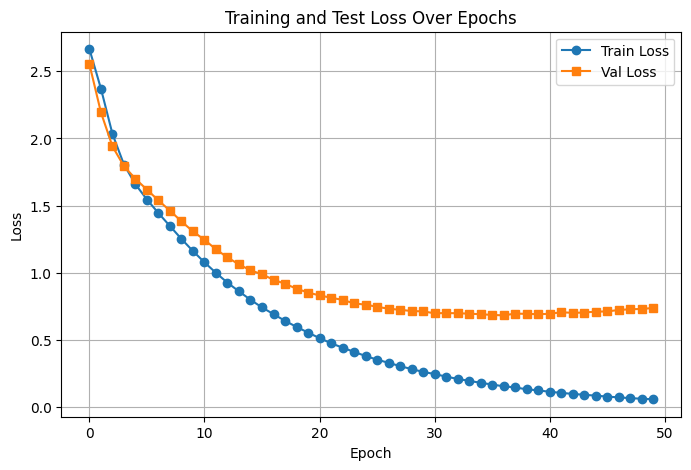

In [52]:
plot_losses(train_loss_history, val_loss_history)

# Performance evaluation

In [59]:
import torch
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def get_predictions_and_confusion(model, test_dataset, batch_size=64):
    """
    Get predictions for the entire test dataset and plot a confusion matrix.
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.eval()

    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    all_labels = []
    all_preds = []
    test_loss = 0.0
    correct = 0
    total = 0
    criterion = nn.CrossEntropyLoss()
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.view(images.size(0), -1).to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)
            test_loss += loss.item() * images.size(0)
            _, preds = outputs.max(1)

            all_labels.append(labels.cpu())
            all_preds.append(preds.cpu())
            
            total += labels.size(0)
            correct += preds.eq(labels).sum().item()

    test_loss /= total
    test_acc = correct / total

    print(f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}")
    
    # Concatenate all batches
    all_labels = torch.cat(all_labels).numpy()
    all_preds = torch.cat(all_preds).numpy()

    # print(all_labels.shape)

    # Compute confusion matrix
    cm = confusion_matrix(all_labels, all_preds, labels=np.arange(15))

    # Plot confusion matrix
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=np.arange(15), yticklabels=np.arange(15))
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")
    plt.show()

    return all_labels, all_preds, cm

Test Loss: 0.8014, Test Acc: 0.7876


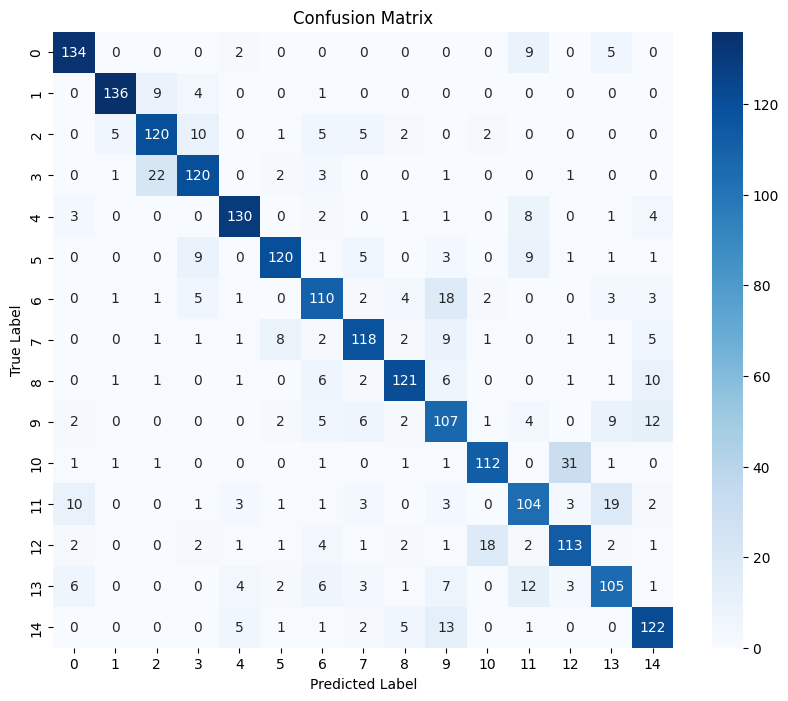

In [60]:
all_labels, all_preds, cm = get_predictions_and_confusion(model, test_dataset)

# Activation function test

In [61]:
def train_model(train_dataset, val_dataset, input_dim, hidden_layers, output_dim,
                activation="sigmoid", batch_size=64, epochs=50, lr=0.001, device=None):
    import torch
    import torch.nn as nn
    import torch.optim as optim
    from torch.utils.data import DataLoader

    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    model = Perceptron(input_dim, hidden_layers, output_dim, activation)
    model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    train_loss_history = []
    train_acc_history = []
    val_loss_history = []
    val_acc_history = []

    best_val_loss = float('inf')
    best_model_state = None

    for epoch in range(1, epochs + 1):
        # --- Training ---
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        for images, labels in train_loader:
            images = images.view(images.size(0), -1).to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        train_loss = running_loss / total
        train_acc = correct / total
        train_loss_history.append(train_loss)
        train_acc_history.append(train_acc)

        # --- Validation ---
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0
        with torch.no_grad():
            for images, labels in val_loader:
                images = images.view(images.size(0), -1).to(device)
                labels = labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * images.size(0)
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()

        val_loss /= total
        val_acc = correct / total
        val_loss_history.append(val_loss)
        val_acc_history.append(val_acc)

        # Save best model state
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = model.state_dict()

        print(f"Epoch [{epoch}/{epochs}] "
              f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

    # Return histories and best model state
    return train_loss_history, train_acc_history, val_loss_history, val_acc_history, best_model_state


In [62]:
activations = ["sigmoid", "relu", "tanh", "leakyrelu", "gelu"]
results = {}

for act in activations:
    print(f"\n=== Training with activation: {act} ===")
    train_loss_hist, train_acc_hist, val_loss_hist, val_acc_hist, best_model_state = \
        train_model(train_dataset, val_dataset,
                    input_dim, hidden_layers, output_dim,
                    activation=act, batch_size=batch_size,
                    epochs=epochs, lr=learning_rate, device=device)

    results[act] = {
        "train_loss": train_loss_hist,
        "train_acc": train_acc_hist,
        "val_loss": val_loss_hist,
        "val_acc": val_acc_hist,
        "best_model_state": best_model_state
    }


=== Training with activation: sigmoid ===
Epoch [1/50] Train Loss: 2.6455, Train Acc: 0.1453 | Val Loss: 2.5015, Val Acc: 0.2631
Epoch [2/50] Train Loss: 2.3255, Train Acc: 0.2811 | Val Loss: 2.1728, Val Acc: 0.3471
Epoch [3/50] Train Loss: 2.0096, Train Acc: 0.3926 | Val Loss: 1.9330, Val Acc: 0.4116
Epoch [4/50] Train Loss: 1.7893, Train Acc: 0.4553 | Val Loss: 1.7780, Val Acc: 0.4684
Epoch [5/50] Train Loss: 1.6456, Train Acc: 0.4979 | Val Loss: 1.6774, Val Acc: 0.4938
Epoch [6/50] Train Loss: 1.5327, Train Acc: 0.5314 | Val Loss: 1.5889, Val Acc: 0.5178
Epoch [7/50] Train Loss: 1.4307, Train Acc: 0.5679 | Val Loss: 1.5098, Val Acc: 0.5342
Epoch [8/50] Train Loss: 1.3370, Train Acc: 0.5970 | Val Loss: 1.4371, Val Acc: 0.5533
Epoch [9/50] Train Loss: 1.2446, Train Acc: 0.6289 | Val Loss: 1.3633, Val Acc: 0.5796
Epoch [10/50] Train Loss: 1.1570, Train Acc: 0.6563 | Val Loss: 1.2956, Val Acc: 0.6013
Epoch [11/50] Train Loss: 1.0745, Train Acc: 0.6847 | Val Loss: 1.2343, Val Acc: 0.612

In [63]:
# Prepare a list to store summary rows
summary_rows = []

for act in activations:
    val_loss_hist = results[act]["val_loss"]
    val_acc_hist = results[act]["val_acc"]

    best_epoch = int(np.argmin(val_loss_hist)) + 1  # epochs start at 1
    best_val_loss = val_loss_hist[best_epoch - 1]
    best_val_acc = val_acc_hist[best_epoch - 1]

    final_val_loss = val_loss_hist[-1]
    final_val_acc = val_acc_hist[-1]

    summary_rows.append({
        "Activation": act,
        "Best Epoch": best_epoch,
        "Best Val Loss": best_val_loss,
        "Val Acc at Best Loss": best_val_acc,
        "Final Val Loss": final_val_loss,
        "Final Val Acc": final_val_acc
    })

# Create DataFrame
summary_df = pd.DataFrame(summary_rows)

# Optional: sort by best validation loss
summary_df = summary_df.sort_values(by="Best Val Loss").reset_index(drop=True)

# Display
print(summary_df)


  Activation  Best Epoch  Best Val Loss  Val Acc at Best Loss  Final Val Loss  \
0    sigmoid          36       0.684596              0.786667        0.728089   
1       relu          10       0.702045              0.788444        1.480918   
2       gelu          10       0.738060              0.782222        1.695604   
3  leakyrelu           8       0.754316              0.779111        1.647239   
4       tanh          17       0.867585              0.746222        1.251293   

   Final Val Acc  
0       0.799556  
1       0.792000  
2       0.792444  
3       0.768444  
4       0.757333  
